In [1]:
from src.data_loader import load_data
from src.preprocess import prepare_data, print_vectorized_sample
from src.ML.train_NN import train_model, print_NN_input_sample, TextClassifier, DeepTextClassifier
from src.predict import predict_single_text
from src.analysis import  intra_category_similarity
from src.plotting import plot_confusion_matrix, plot_learning_curve, plot_metrics_bar_chart
from src.ML.train_svm import train_SVM
from src.ML.train_rf import train_random_forest

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
plt.rcParams["figure.figsize"] = (3,2)






DATA_PATH = "/home/xkubanova_126831/bakalarka/e_com_dataset/data/ecommerceDataset.csv"

In [2]:
# dataset structure:
# samples: 50 425
# categories: 4 (Househols, Electronics, Books, Clothing & Accessories)
# percentage: household: 38%, books: 24%, electronics: 21%, clothing & accessories: 17%

print("--- 1. Loading and Preparing Data ---")
df = load_data("/home/xkubanova_126831/bakalarka/e_com_dataset/data/ecommerceDataset.csv")





--- 1. Loading and Preparing Data ---
Dataset shape: (50425, 2)

Categories samples:

Books:
  Inner Engineering: A Yogi's Guide to Joy About the Author Sadhguru Jaggi VasudevSADHGURU is a yogi, mystic, and visionary who established the Isha Foundation, a nonprofit dedicated to the cultivation of human potential. He belongs to no particular tradition, and his scientific methods for self-transformation have universal appeal. Sadhguru has been an in?uential voice at global forums including th...

Clothing & Accessories:
  Woopower 36M Pink for 024M Baby Trouser Top Sets3Pcs Boy Girl Hooded Topsstriped Pantshairband Outfits36Mpink Size name36m colourpink description100 brand new and type children setgender unisexfor season autumn springcoloroptional pink greensize table 7080 90 100cminchsize tops length bust pants length age70 32 1260 46 1811 37 1457 36m80 34 1339 48 1890 39 1535 612m90 36 1417 52 2047 41 1614 1218m...

Electronics:
  Dell 19.5V-3.34AMP 65W Laptop Adapter (Without power C

Simple Feed Forward NN
Class weights: tensor([1.0665, 1.4538, 1.1869, 0.6528])
Test accuracy: 0.9734
                        precision    recall  f1-score   support

                 Books     0.9766    0.9691    0.9728      2364
Clothing & Accessories     0.9766    0.9850    0.9808      1734
           Electronics     0.9666    0.9685    0.9675      2124
             Household     0.9738    0.9736    0.9737      3863

              accuracy                         0.9734     10085
             macro avg     0.9734    0.9740    0.9737     10085
          weighted avg     0.9734    0.9734    0.9734     10085

Test accuracy: 0.9734


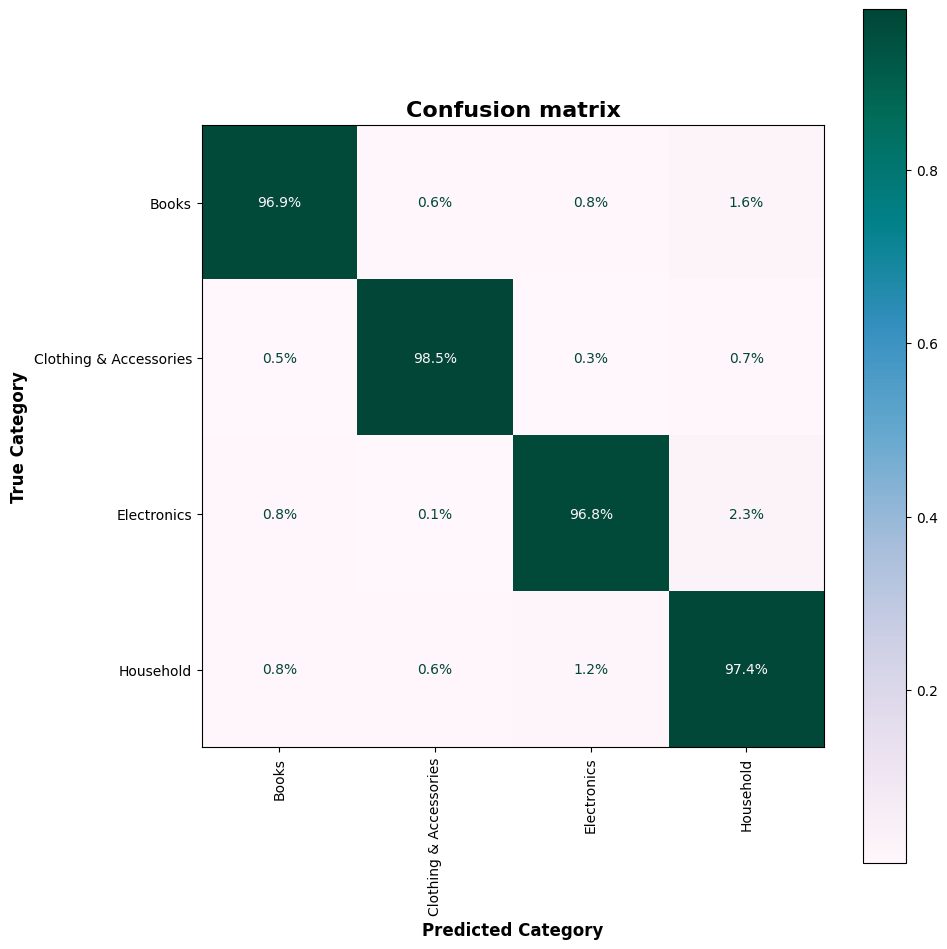

<Figure size 300x200 with 0 Axes>

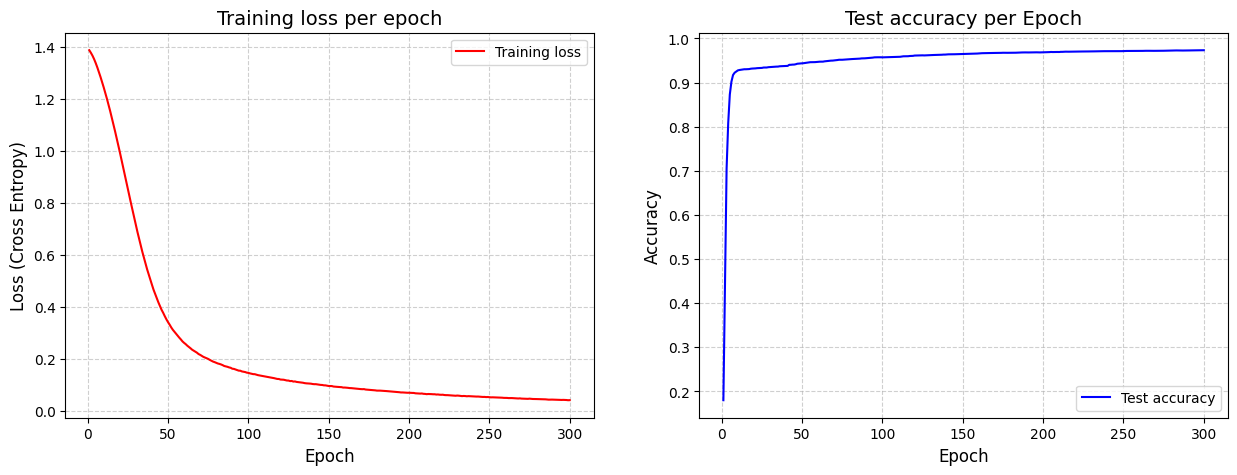

<Figure size 300x200 with 0 Axes>

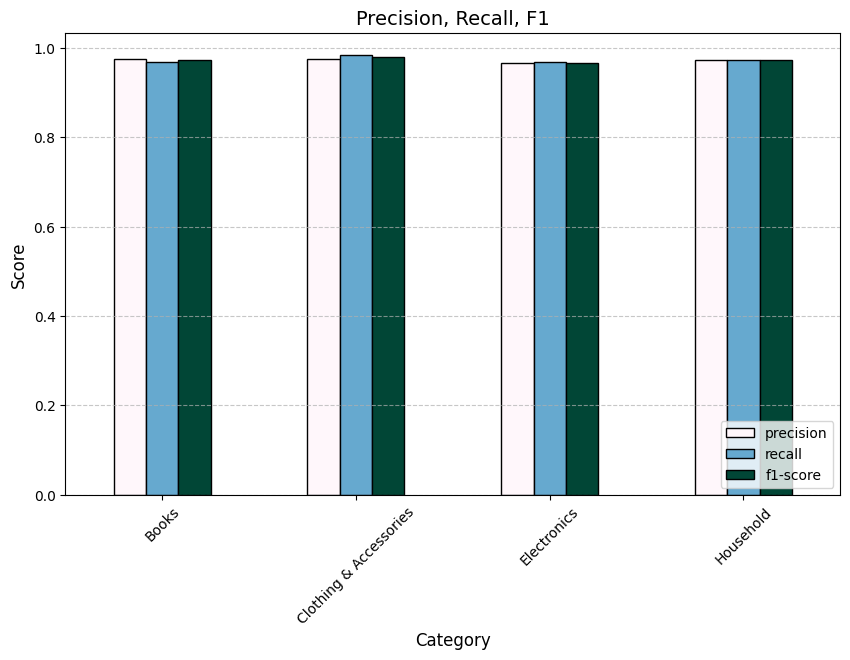

<Figure size 300x200 with 0 Axes>

In [3]:
from src.ML.train_NN import TextClassifier

#prepare data
X_train, X_test, y_train, y_test, vectorizer = prepare_data(df)

print("Simple Feed Forward NN")

simple_model, class_to_idx, simple_acc = train_model(
    X_train, y_train, X_test, y_test,
    model_class=TextClassifier,
    model_params={"hidden_dim": 256},
    epochs=300,
    lr=0.001
)


Deep Feed Forward NN
Class weights: tensor([1.0665, 1.4538, 1.1869, 0.6528])
Test accuracy: 0.9763
                        precision    recall  f1-score   support

                 Books     0.9782    0.9700    0.9741      2364
Clothing & Accessories     0.9755    0.9856    0.9805      1734
           Electronics     0.9750    0.9718    0.9734      2124
             Household     0.9762    0.9785    0.9774      3863

              accuracy                         0.9763     10085
             macro avg     0.9762    0.9765    0.9763     10085
          weighted avg     0.9763    0.9763    0.9763     10085

Test accuracy: 0.9763


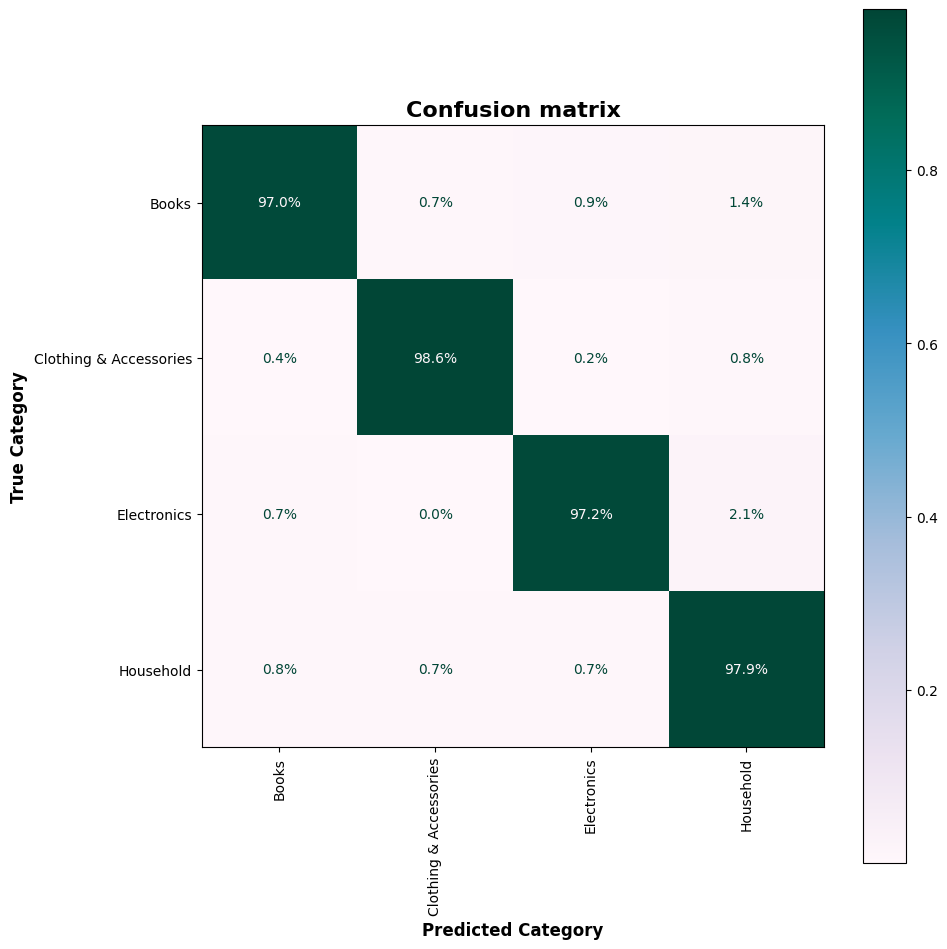

<Figure size 300x200 with 0 Axes>

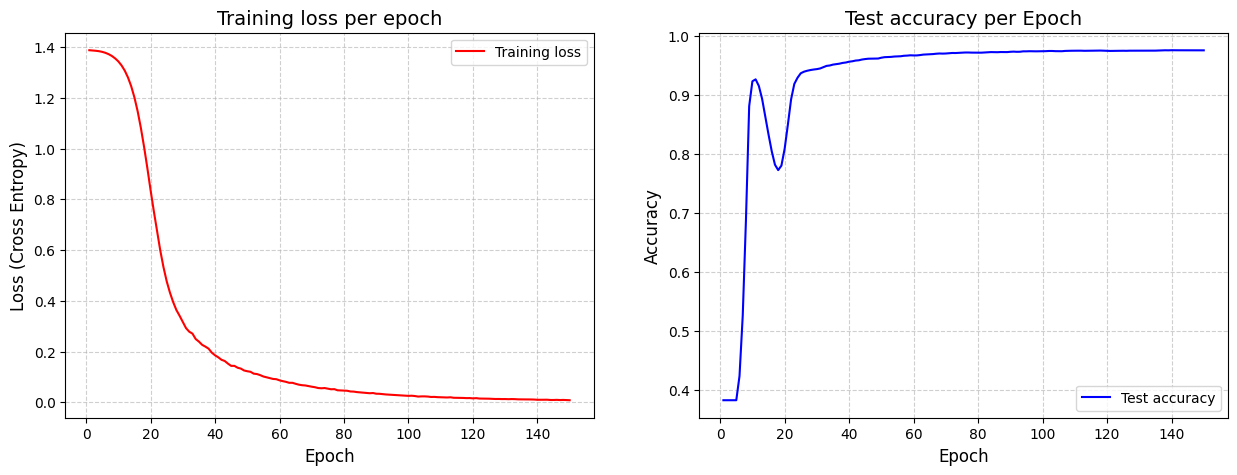

<Figure size 300x200 with 0 Axes>

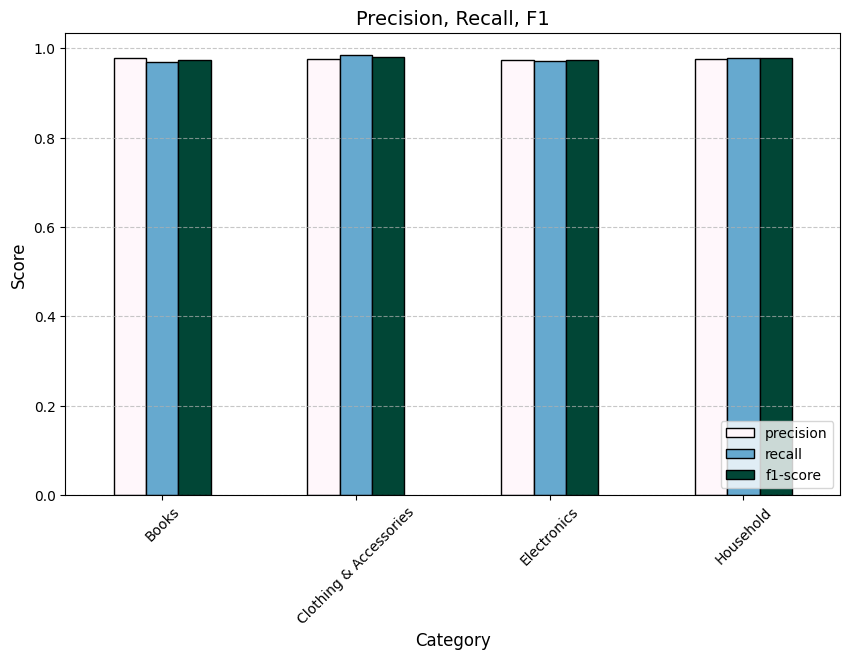

<Figure size 300x200 with 0 Axes>

In [4]:
from src.ML.train_NN import DeepTextClassifier

#prepare data
X_train, X_test, y_train, y_test, vectorizer = prepare_data(df)

print("Deep Feed Forward NN")

deep_model, class_to_idx, deep_acc = train_model(
    X_train, y_train, X_test, y_test,
    model_class=DeepTextClassifier,
    model_params={"hidden_dims": [512, 256, 128, 64]},
    epochs=150,
    lr=0.001
)


In [5]:
import os
hf_token = os.getenv("HF_TOKEN")

import re

from sklearn.model_selection import train_test_split
import gensim.downloader     #na nacitanie predtrenovaneho word2vec modelu
from nltk.tokenize import word_tokenize
import nltk     #natural language processing
nltk.download('punkt', quiet=True)

from src.LM.embeddings.embedder_preprocess import clean_text
from src.LM.embeddings.embedder_preprocess import load_word2vec_model
from src.LM.embeddings.embedder_preprocess import text_to_vector
from src.LM.embeddings.embedder_preprocess import prepare_data_word2vec

Dataset shape: (50425, 2)

Categories samples:

Books:
  Inner Engineering: A Yogi's Guide to Joy About the Author Sadhguru Jaggi VasudevSADHGURU is a yogi, mystic, and visionary who established the Isha Foundation, a nonprofit dedicated to the cultivation of human potential. He belongs to no particular tradition, and his scientific methods for self-transformation have universal appeal. Sadhguru has been an in?uential voice at global forums including th...

Clothing & Accessories:
  Woopower 36M Pink for 024M Baby Trouser Top Sets3Pcs Boy Girl Hooded Topsstriped Pantshairband Outfits36Mpink Size name36m colourpink description100 brand new and type children setgender unisexfor season autumn springcoloroptional pink greensize table 7080 90 100cminchsize tops length bust pants length age70 32 1260 46 1811 37 1457 36m80 34 1339 48 1890 39 1535 612m90 36 1417 52 2047 41 1614 1218m...

Electronics:
  Dell 19.5V-3.34AMP 65W Laptop Adapter (Without power Cord) Design Features of Dell Laptop - 

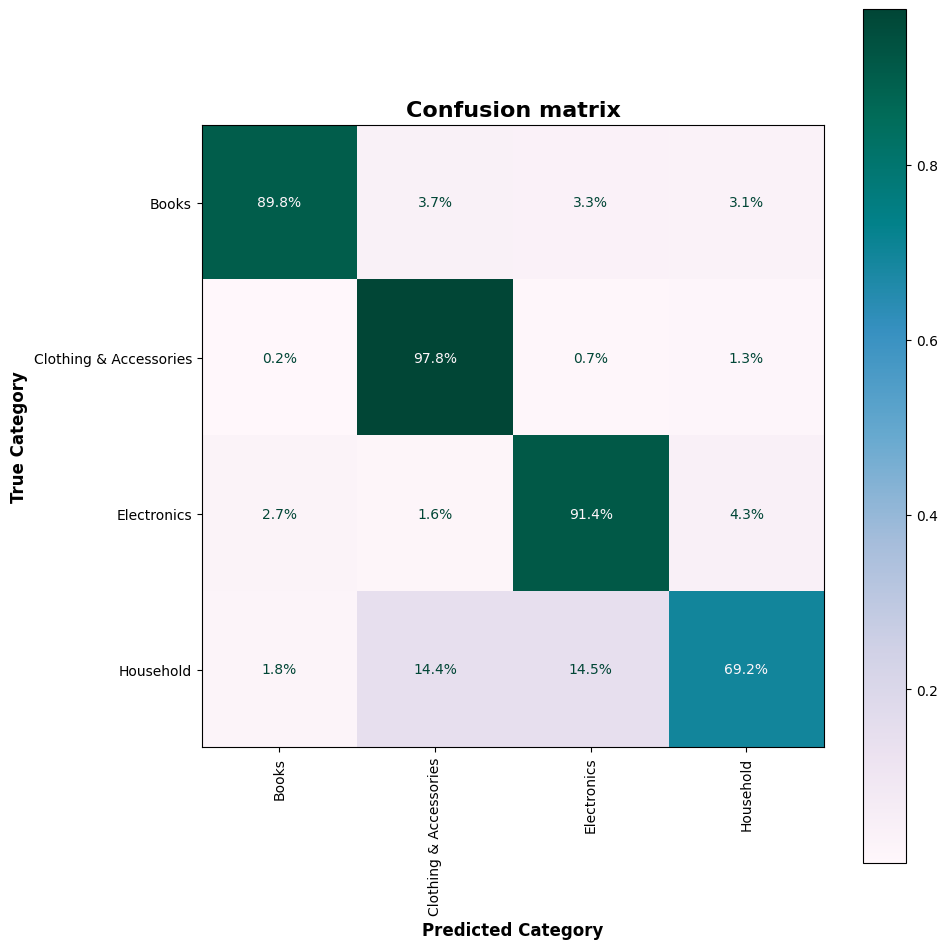

<Figure size 300x200 with 0 Axes>

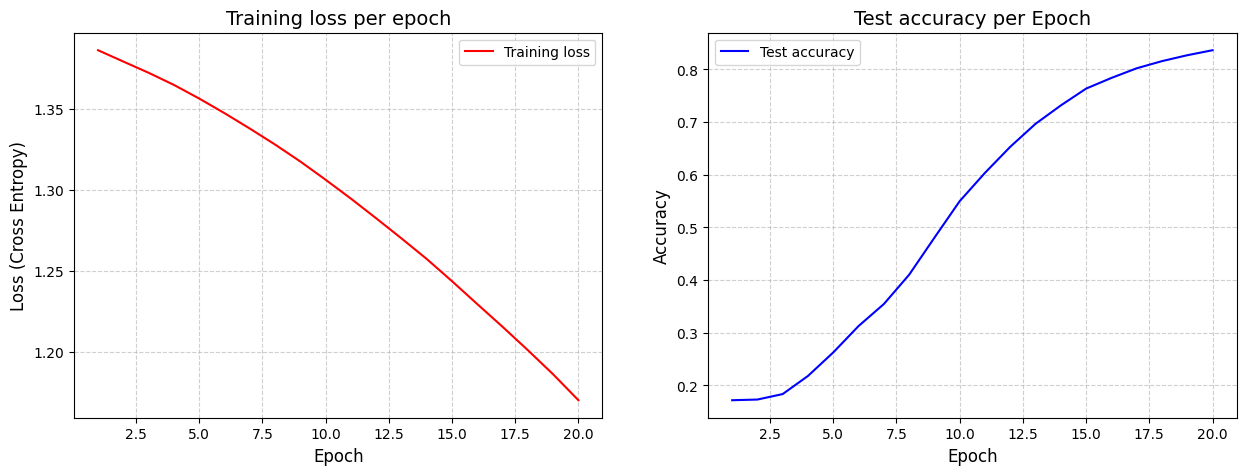

<Figure size 300x200 with 0 Axes>

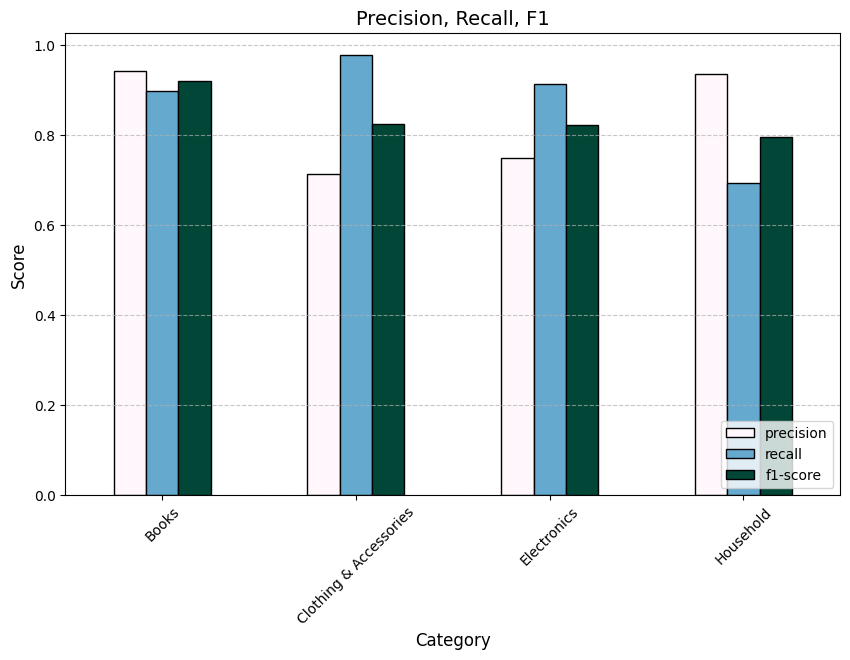

<Figure size 300x200 with 0 Axes>

In [6]:

df = load_data("/home/xkubanova_126831/bakalarka/e_com_dataset/data/ecommerceDataset.csv")
df["Text"] = df["Text"].apply(clean_text)
# nacitanie predtrenovaneho modelu (300 dimenzionalny)
w2vmodel = load_word2vec_model()
print("Model loaded. Vector size:", w2vmodel.vector_size) # 300
print(df["Category"].value_counts(normalize=True))


X_train_vec, X_test_vec, y_train, y_test, w2v_model = prepare_data_word2vec(df)
model, class_to_idx, acc = train_model(
    X_train_vec, y_train, X_test_vec, y_test,
    model_class=TextClassifier,
    model_params={"hidden_dim": 128},
    epochs=20,
    lr=0.001
)

Dataset shape: (50425, 2)

Categories samples:

Books:
  Inner Engineering: A Yogi's Guide to Joy About the Author Sadhguru Jaggi VasudevSADHGURU is a yogi, mystic, and visionary who established the Isha Foundation, a nonprofit dedicated to the cultivation of human potential. He belongs to no particular tradition, and his scientific methods for self-transformation have universal appeal. Sadhguru has been an in?uential voice at global forums including th...

Clothing & Accessories:
  Woopower 36M Pink for 024M Baby Trouser Top Sets3Pcs Boy Girl Hooded Topsstriped Pantshairband Outfits36Mpink Size name36m colourpink description100 brand new and type children setgender unisexfor season autumn springcoloroptional pink greensize table 7080 90 100cminchsize tops length bust pants length age70 32 1260 46 1811 37 1457 36m80 34 1339 48 1890 39 1535 612m90 36 1417 52 2047 41 1614 1218m...

Electronics:
  Dell 19.5V-3.34AMP 65W Laptop Adapter (Without power Cord) Design Features of Dell Laptop - 

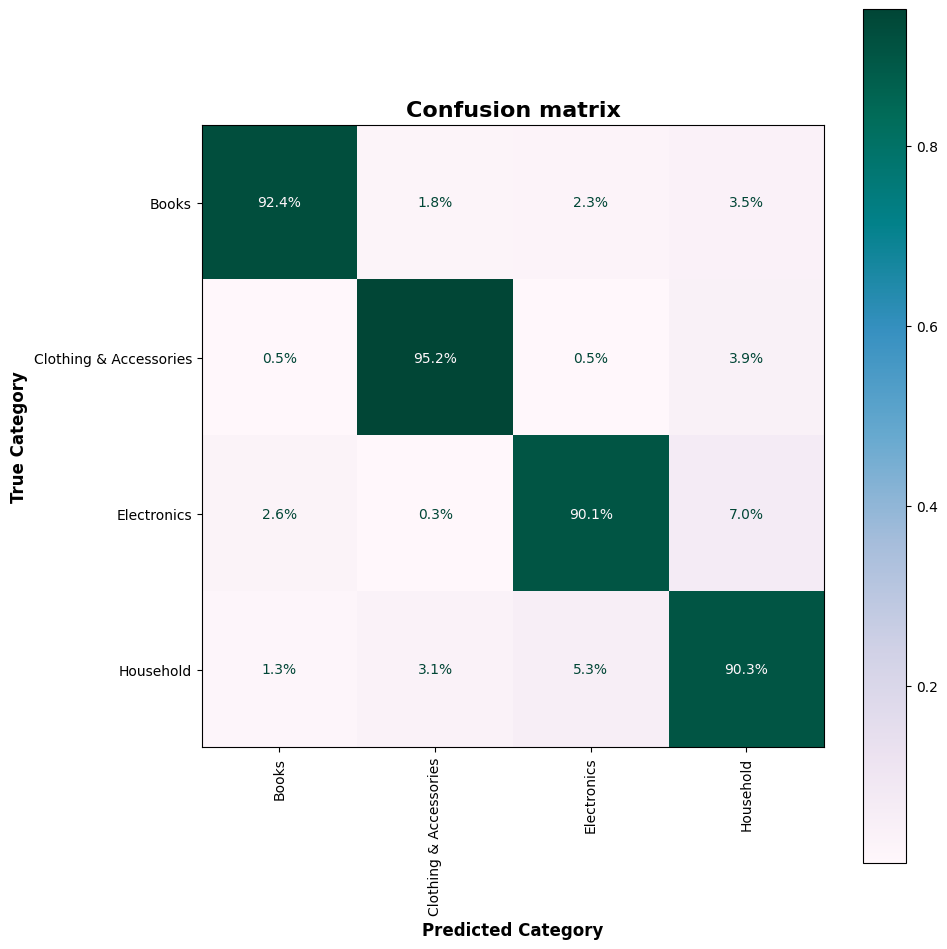

<Figure size 300x200 with 0 Axes>

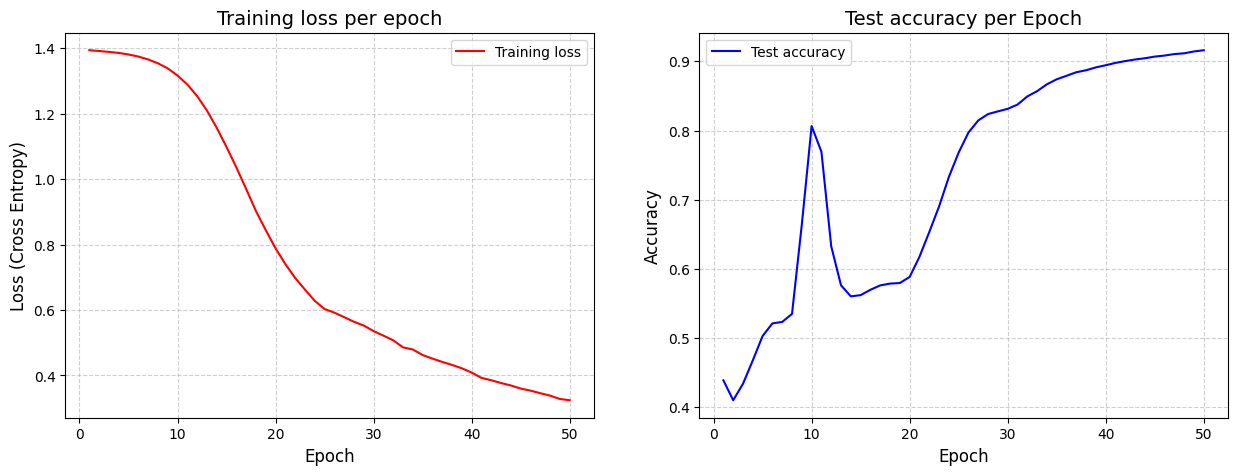

<Figure size 300x200 with 0 Axes>

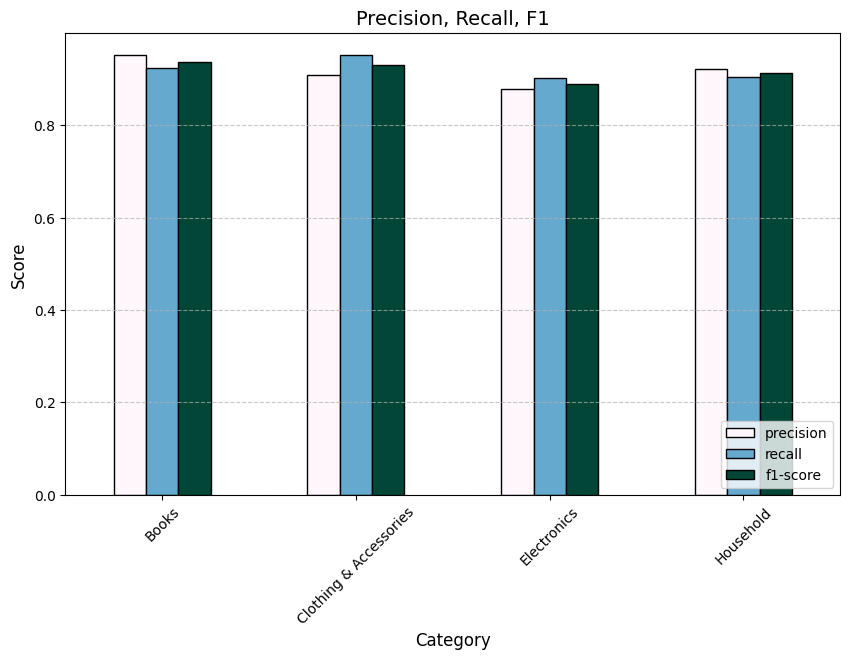

<Figure size 300x200 with 0 Axes>

In [7]:
df = load_data("/home/xkubanova_126831/bakalarka/e_com_dataset/data/ecommerceDataset.csv")
df["Text"] = df["Text"].apply(clean_text)
# nacitanie predtrenovaneho modelu (300 dimenzionalny)
w2vmodel = load_word2vec_model()
print("Model loaded. Vector size:", w2vmodel.vector_size) # 300
print(df["Category"].value_counts(normalize=True))


X_train_vec, X_test_vec, y_train, y_test, w2v_model = prepare_data_word2vec(df)
model, class_to_idx, acc = train_model(
    X_train_vec, y_train, X_test_vec, y_test,
    model_class=DeepTextClassifier,
    model_params={"hidden_dims": [512, 256, 128, 64]},
    epochs=50,
    lr=0.001
)

Dataset shape: (50425, 2)

Categories samples:

Books:
  Inner Engineering: A Yogi's Guide to Joy About the Author Sadhguru Jaggi VasudevSADHGURU is a yogi, mystic, and visionary who established the Isha Foundation, a nonprofit dedicated to the cultivation of human potential. He belongs to no particular tradition, and his scientific methods for self-transformation have universal appeal. Sadhguru has been an in?uential voice at global forums including th...

Clothing & Accessories:
  Woopower 36M Pink for 024M Baby Trouser Top Sets3Pcs Boy Girl Hooded Topsstriped Pantshairband Outfits36Mpink Size name36m colourpink description100 brand new and type children setgender unisexfor season autumn springcoloroptional pink greensize table 7080 90 100cminchsize tops length bust pants length age70 32 1260 46 1811 37 1457 36m80 34 1339 48 1890 39 1535 612m90 36 1417 52 2047 41 1614 1218m...

Electronics:
  Dell 19.5V-3.34AMP 65W Laptop Adapter (Without power Cord) Design Features of Dell Laptop - 

Encoding batches: 100%|██████████| 2522/2522 [01:01<00:00, 40.81it/s]


Class weights: tensor([1.0665, 1.4538, 1.1869, 0.6528])
Test accuracy: 0.8798
                        precision    recall  f1-score   support

                 Books     0.9375    0.8625    0.8984      2364
Clothing & Accessories     0.8054    0.9475    0.8707      1734
           Electronics     0.8321    0.9171    0.8726      2124
             Household     0.9190    0.8395    0.8774      3863

              accuracy                         0.8798     10085
             macro avg     0.8735    0.8917    0.8798     10085
          weighted avg     0.8855    0.8798    0.8802     10085

Test accuracy: 0.8798


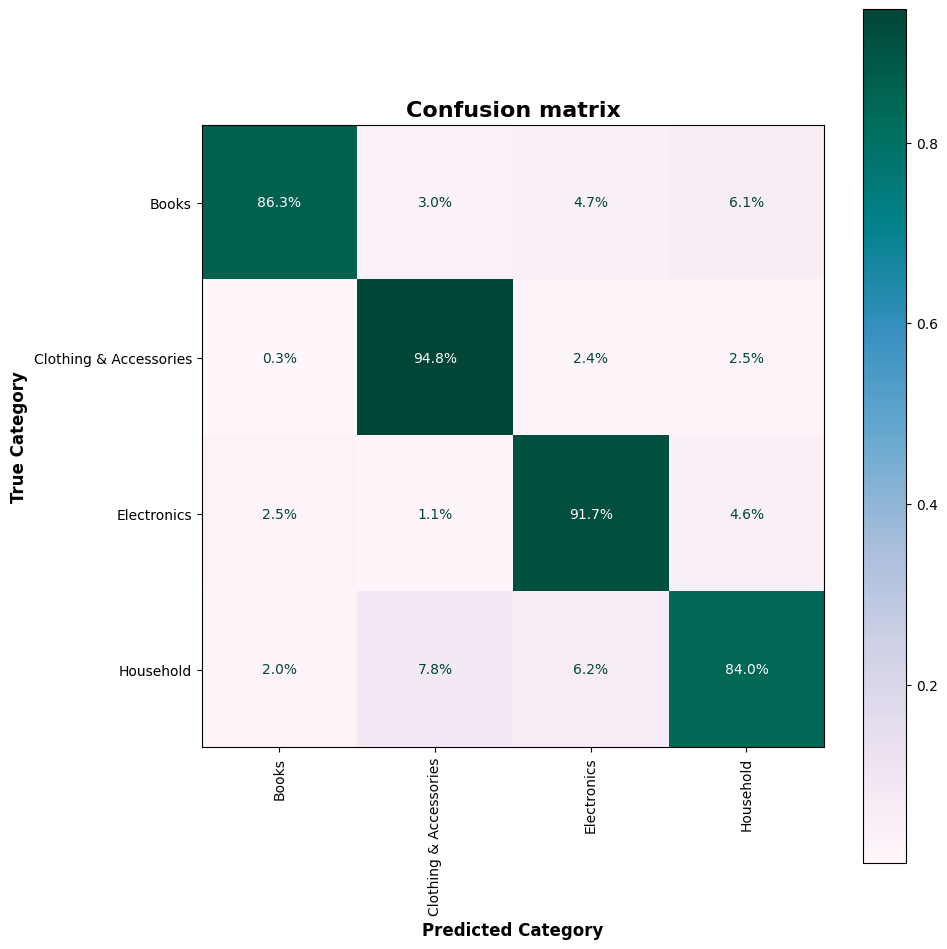

<Figure size 300x200 with 0 Axes>

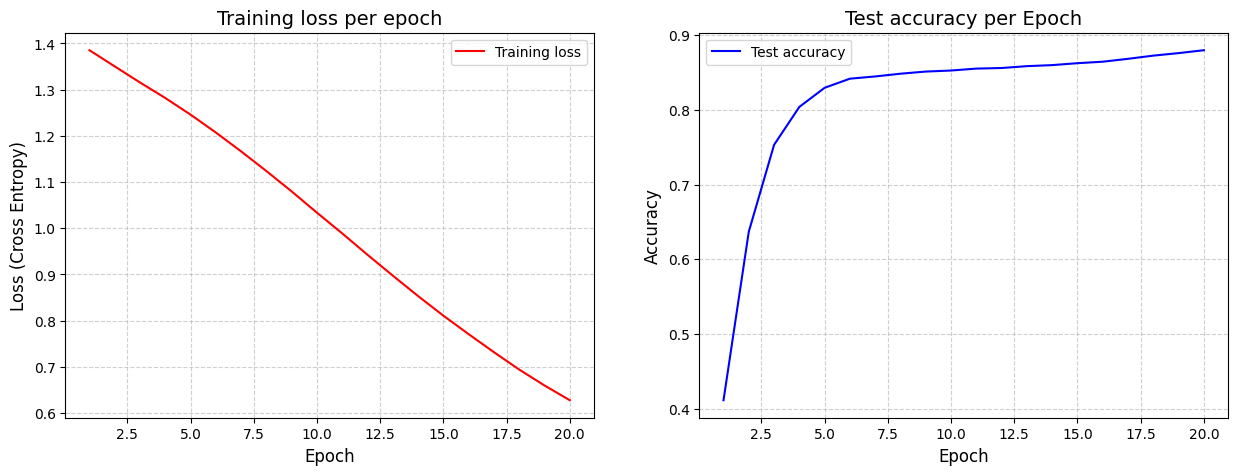

<Figure size 300x200 with 0 Axes>

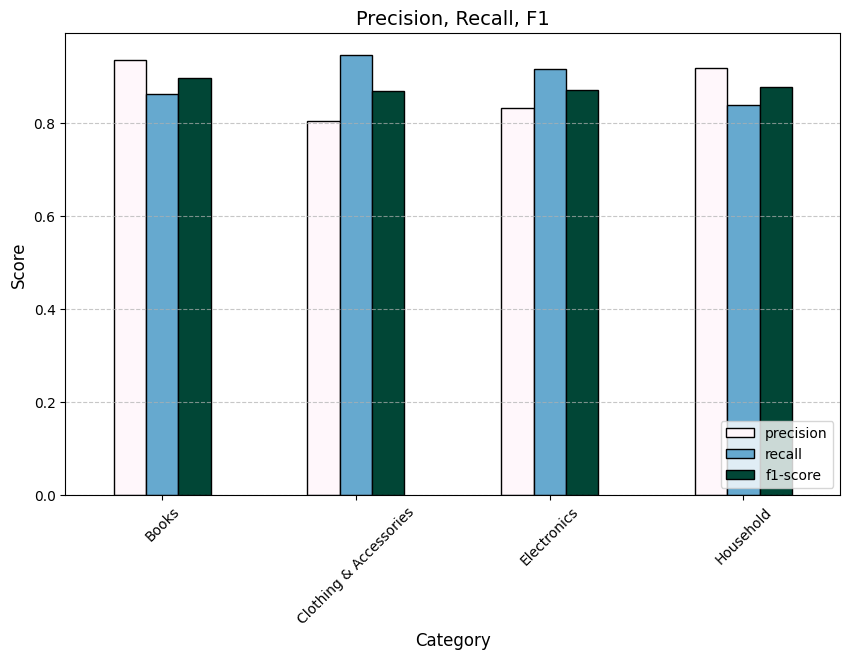

<Figure size 300x200 with 0 Axes>

In [14]:
from transformers import AutoTokenizer, AutoModel
import torch

from src.LM.embeddings.embedder_preprocess import load_minilm_embedder, prepare_data_minilm

# Load your dataset
df = load_data("/home/xkubanova_126831/bakalarka/e_com_dataset/data/ecommerceDataset.csv")

print(df["Category"].value_counts(normalize=True))


device = "cpu"
print('using devide:', device)
tokenizer, minilm_model = load_minilm_embedder("sentence-transformers/all-MiniLM-L6-v2", device=device)
minilm_model.eval()  # set to evaluation mode

# Convert text to BERT embeddings
X_train_vec, X_test_vec, y_train, y_test = prepare_data_minilm(df, tokenizer, minilm_model, device=device, batch_size = 4)



# Train your classifier with BERT embeddings
model, class_to_idx, acc = train_model(
    X_train_vec, y_train, X_test_vec, y_test,
    model_class=TextClassifier,
    model_params={"hidden_dim": 128},
    epochs=20,
    lr=0.001
)
